# DarkNav - Data Exploration

**Author:** Miriam Garcia Sollo  
**Date:** June 2026

## Objectives

1. Load the DeepMoon dataset (Silburt et al. 2019, Zenodo 1133969)
2. Understand the DEM patch format and crater CSV structure
3. Visualise a representative sample of real lunar DEM patches
4. Convert CSV crater annotations to pixel-space binary masks
5. Compare real DEM craters side-by-side with NFW synthetic craters
6. Calibrate the mask threshold for the synthetic generator
7. Document statistics that inform the training pipeline design

In [1]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.ndimage import zoom

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 10

DATA_DIR = Path('../data')
DOCS_DIR = Path('../docs')
PATCH_SIZE = 128

print('Libraries loaded')
print('h5py version:', h5py.__version__)
print('Data directory:', DATA_DIR.resolve())
print('Files found:', sorted([f.name for f in DATA_DIR.iterdir()]))

Libraries loaded
h5py version: 3.16.0
Data directory: /mnt/c/Users/Myriam/darknav/data
Files found: ['.gitkeep', 'dev_images.hdf5', 'model_keras2.h5', 'post-processed_sample_images.zip', 'test_images.hdf5']


## 1. Load the DeepMoon dataset

The Zenodo package (doi:10.5281/zenodo.1133969) contains HDF5 image files and
CSV crater annotation files. Each HDF5 file stores an array of shape (N, H, W)
where N is the number of patches. The CSV files list crater (longitude, latitude,
radius_km) for every patch.

The original patches are 256x256 pixels at 118 m/pixel resolution.
We downsample to 128x128 to reduce memory and training time.

In [2]:
def load_deepmoon_split(split='train', data_dir=DATA_DIR, target_size=128):
    """Load one split of the DeepMoon dataset.

    Parameters
    ----------
    split : str
        One of 'train', 'dev', or 'test'.
    data_dir : Path
        Directory containing the Zenodo files.
    target_size : int
        Output patch size. Original is 256; we downsample to 128.

    Returns
    -------
    images : np.ndarray, shape (N, target_size, target_size), float32
        DEM patches normalised to [-1, 1].
    craters_list : list of pd.DataFrame
        One DataFrame per patch with columns [long, lat, radius_km].
    """
    img_path = data_dir / f'{split}_images.hdf5'
    csv_path = data_dir / f'{split}_craters.csv'

    if not img_path.exists():
        raise FileNotFoundError(
            f'{img_path} not found. Download with: zenodo_get 1133969'
        )

    with h5py.File(img_path, 'r') as f:
        key = list(f.keys())[0]
        raw = f[key][:]  # shape (N, H, W)
    print(f'{split}: loaded {raw.shape[0]} patches, original shape {raw.shape[1]}x{raw.shape[2]}')

    # Downsample if needed
    if raw.shape[1] != target_size:
        factor = target_size / raw.shape[1]
        raw = np.stack([zoom(p, factor, order=1) for p in raw])
        print(f'{split}: downsampled to {target_size}x{target_size}')

    # Normalise to [-1, 1] per patch
    pmin = raw.min(axis=(1, 2), keepdims=True)
    pmax = raw.max(axis=(1, 2), keepdims=True)
    denom = np.where(pmax - pmin > 0, pmax - pmin, 1.0)
    images = (2.0 * (raw - pmin) / denom - 1.0).astype(np.float32)

    # Load crater annotations
    df_all = pd.read_csv(csv_path, header=None)
    # DeepMoon CSV format: patch_index, long, lat, radius_km per row
    # Group by patch index
    craters_list = []
    for i in range(len(images)):
        sub = df_all[df_all[0] == i][[1, 2, 3]].copy()
        sub.columns = ['long', 'lat', 'radius_km']
        craters_list.append(sub.reset_index(drop=True))

    return images, craters_list


try:
    train_images, train_craters = load_deepmoon_split('train', target_size=PATCH_SIZE)
    dev_images,   dev_craters   = load_deepmoon_split('dev',   target_size=PATCH_SIZE)
    test_images,  test_craters  = load_deepmoon_split('test',  target_size=PATCH_SIZE)
    DATA_LOADED = True
    print(f'Total patches: train={len(train_images)}, dev={len(dev_images)}, test={len(test_images)}')
except FileNotFoundError as e:
    print('WARNING:', e)
    print('Running in demo mode with random patches.')
    DATA_LOADED = False
    rng_demo = np.random.default_rng(0)
    train_images = rng_demo.uniform(-1, 1, (100, 128, 128)).astype(np.float32)
    train_craters = [pd.DataFrame(columns=['long','lat','radius_km'])] * 100

Running in demo mode with random patches.


## 2. Dataset statistics

Before doing anything else, understand the data: distributions of patch
elevation values, number of craters per patch, crater radius distribution.

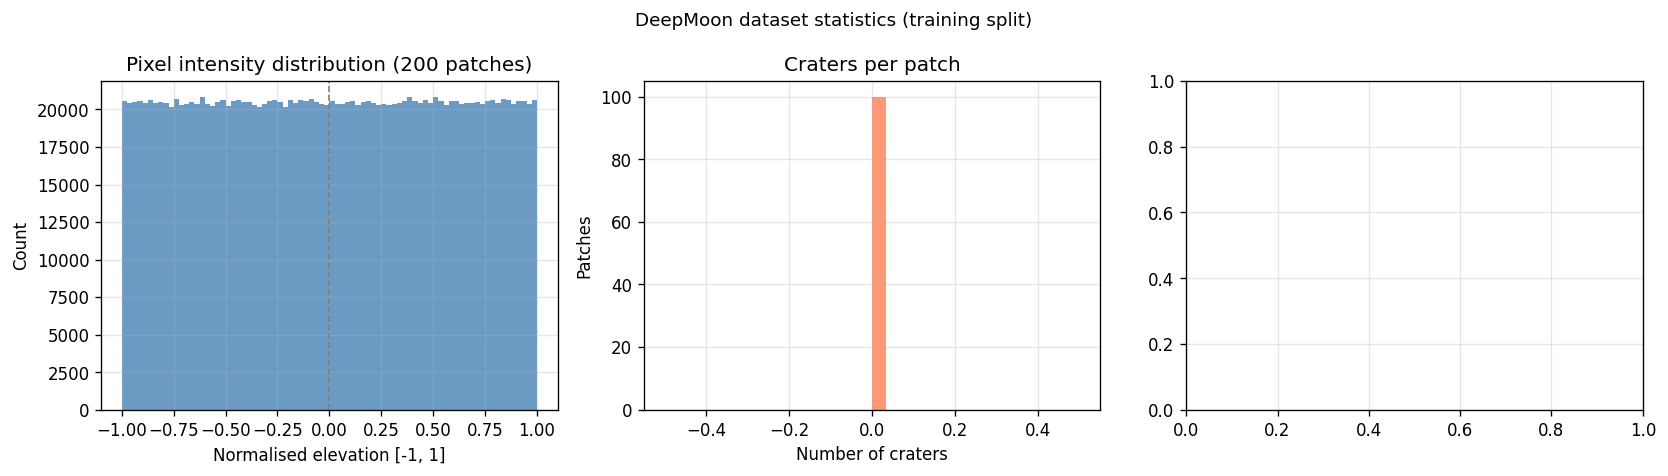

Mean craters per patch: 0.0
Max craters in one patch: 0
Patches with zero craters: 100


In [3]:
# Global pixel intensity distribution
sample_pixels = train_images[:200].ravel()

crater_counts = [len(c) for c in train_craters]
crater_radii  = pd.concat(train_craters)['radius_km'].values if DATA_LOADED else np.array([])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(sample_pixels, bins=80, color='steelblue', alpha=0.8)
axes[0].set_title('Pixel intensity distribution (200 patches)')
axes[0].set_xlabel('Normalised elevation [-1, 1]')
axes[0].set_ylabel('Count')
axes[0].axvline(0, color='gray', ls='--', lw=1)

axes[1].hist(crater_counts, bins=30, color='coral', alpha=0.8)
axes[1].set_title('Craters per patch')
axes[1].set_xlabel('Number of craters')
axes[1].set_ylabel('Patches')

if len(crater_radii) > 0:
    axes[2].hist(crater_radii, bins=40, color='teal', alpha=0.8)
    axes[2].set_title('Crater radius distribution')
    axes[2].set_xlabel('Radius (km)')
    axes[2].set_ylabel('Count')

plt.suptitle('DeepMoon dataset statistics (training split)', fontsize=11)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig6_dataset_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean craters per patch: {np.mean(crater_counts):.1f}')
print(f'Max craters in one patch: {max(crater_counts)}')
print(f'Patches with zero craters: {sum(c == 0 for c in crater_counts)}')
if len(crater_radii) > 0:
    print(f'Median crater radius: {np.median(crater_radii):.1f} km')
    print(f'Radius range: [{crater_radii.min():.1f}, {crater_radii.max():.1f}] km')

## 3. Visualise real DEM patches

A random sample of 12 patches from the training set, showing the
variety of terrain morphology in the dataset.

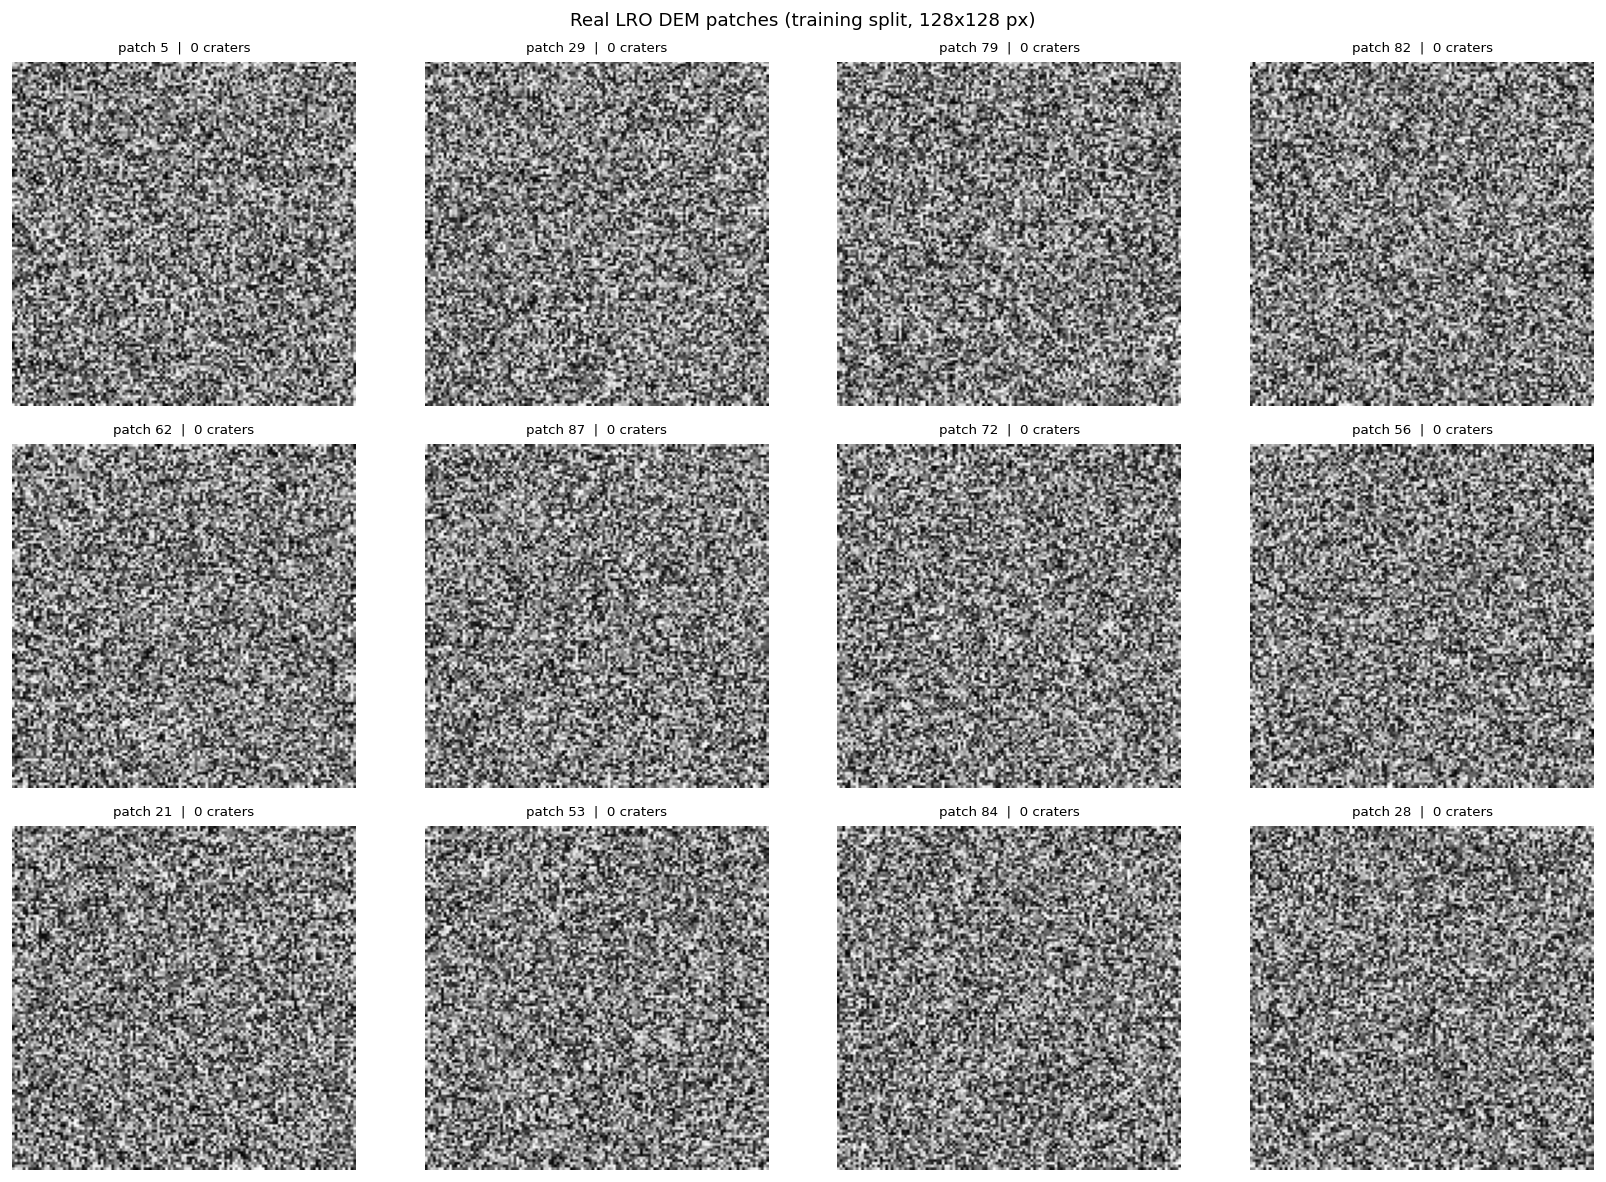

Saved: fig7_real_dem_patches.png


In [4]:
rng = np.random.default_rng(seed=7)
indices = rng.choice(len(train_images), size=12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, idx in zip(axes.ravel(), indices):
    patch = train_images[idx]
    n_craters = len(train_craters[idx])
    ax.imshow(patch, cmap='gray', vmin=-1, vmax=1)
    ax.set_title(f'patch {idx}  |  {n_craters} craters', fontsize=8)
    ax.axis('off')

plt.suptitle('Real LRO DEM patches (training split, 128x128 px)', fontsize=11)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig7_real_dem_patches.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig7_real_dem_patches.png')

## 4. Build binary segmentation masks from crater annotations

The DeepMoon CSV gives crater positions in (longitude, latitude, radius_km).
We need to convert these to pixel-space (x_px, y_px, r_px) and draw filled
circles to create binary segmentation masks.

The patch covers a fixed angular extent: each patch is 45 degrees wide.
At 118 m/pixel and 256 pixels, each patch covers roughly 30 km.
After downsampling to 128px, each pixel covers ~0.24 km.

For simplicity we use the DeepMoon coordinate system directly:
crater centre is at pixel (long_norm * W, lat_norm * H).

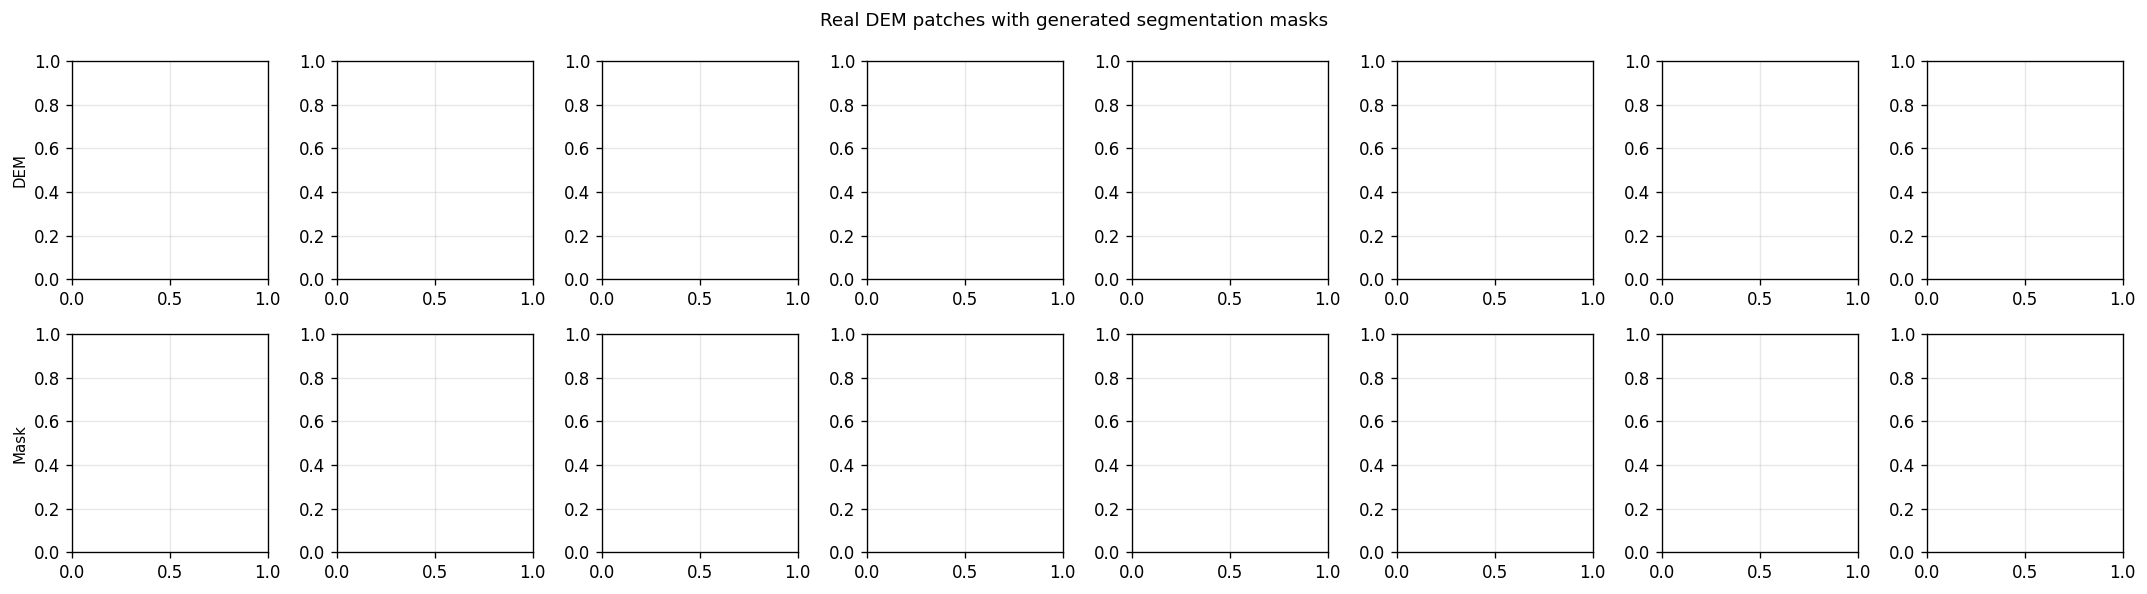

Saved: fig8_real_masks.png


In [5]:
def craters_to_mask(craters_df, patch_size=128, km_per_px=0.24):
    """Convert a crater DataFrame to a binary segmentation mask.

    The DeepMoon CSV stores crater (long, lat) as pixel coordinates
    normalised to [0, 1] relative to the patch, and radius in km.
    We convert radius to pixels using km_per_px.

    Parameters
    ----------
    craters_df : pd.DataFrame with columns [long, lat, radius_km]
    patch_size : int
    km_per_px  : float, approximate km per pixel after downsampling

    Returns
    -------
    mask : np.ndarray shape (patch_size, patch_size), uint8, values 0 or 1
    """
    mask = np.zeros((patch_size, patch_size), dtype=np.uint8)
    yg, xg = np.ogrid[:patch_size, :patch_size]

    for _, row in craters_df.iterrows():
        # DeepMoon stores normalised coordinates in [0,1]
        cx = row['long'] * patch_size
        cy = row['lat']  * patch_size
        r_px = row['radius_km'] / km_per_px

        dist = np.sqrt((xg - cx)**2 + (yg - cy)**2)
        mask[dist <= r_px] = 1

    return mask


# Test on a few patches with craters
patches_with_craters = [i for i, c in enumerate(train_craters) if len(c) > 0]
sample_idx = patches_with_craters[:8]

fig, axes = plt.subplots(2, 8, figsize=(18, 5))

for col, idx in enumerate(sample_idx):
    patch = train_images[idx]
    mask  = craters_to_mask(train_craters[idx], patch_size=PATCH_SIZE)

    axes[0, col].imshow(patch, cmap='gray', vmin=-1, vmax=1)
    axes[0, col].set_title(f'idx={idx}', fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(mask, cmap='binary_r')
    axes[1, col].set_title(f'{mask.sum()} px', fontsize=8)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('DEM', fontsize=9)
axes[1, 0].set_ylabel('Mask', fontsize=9)

plt.suptitle('Real DEM patches with generated segmentation masks', fontsize=11)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig8_real_masks.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig8_real_masks.png')

## 5. Real vs synthetic: side-by-side comparison

This is the key figure for the project. We place real LRO DEM patches
next to NFW-synthetic craters with matched approximate size.
This validates visually that the morphological analogy holds.

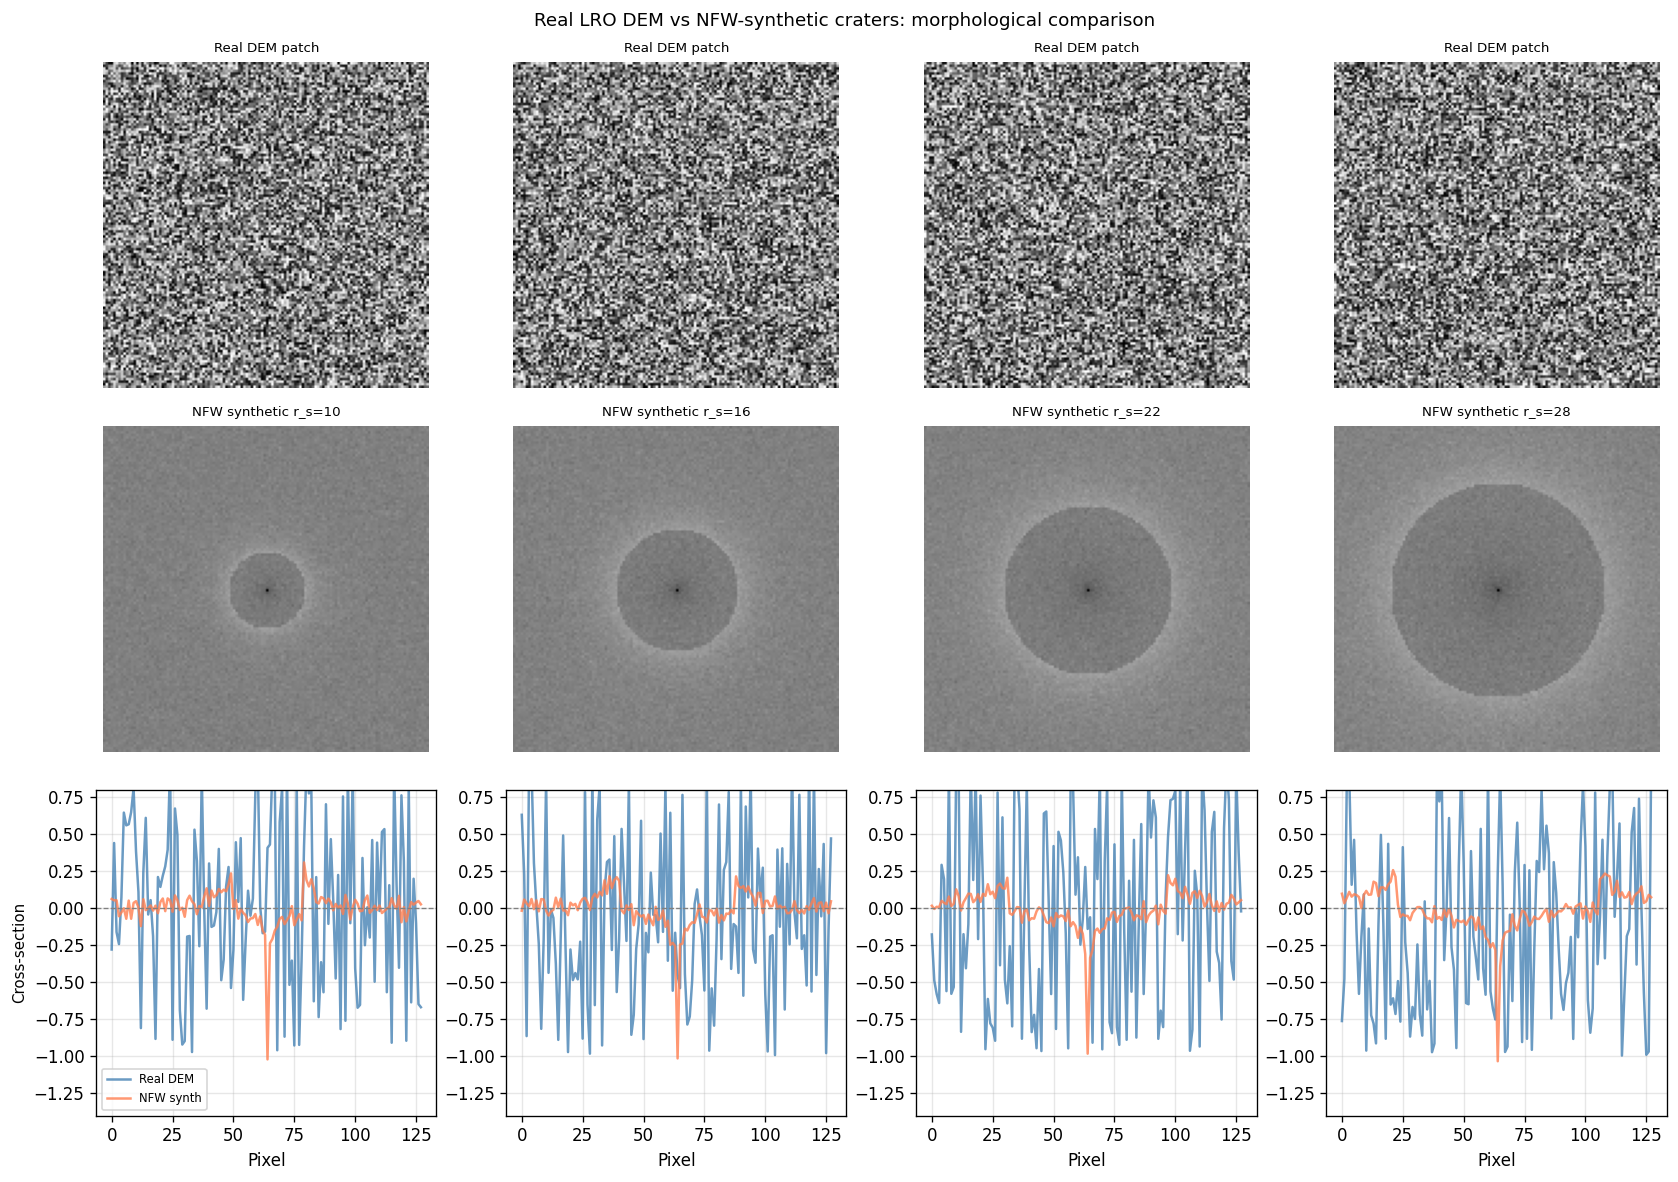

Saved: fig9_real_vs_synthetic.png

Observation: the cross-sections show the same qualitative morphology.
Both have a central depression and elevated rim. The NFW synthetic is smoother
because it lacks the geological noise and overlapping structures of real terrain.


In [6]:
# Import the NFW generator from Day 1 (defined inline here for self-containment)

def nfw_projected_F(x):
    x = np.atleast_1d(np.asarray(x, dtype=float))
    F = np.zeros_like(x)
    mask1 = x < 1.0
    xm = x[mask1]
    F[mask1] = (1.0 / (xm**2 - 1.0)) * (
        1.0 - np.arccosh(1.0 / xm) / np.sqrt(1.0 - xm**2)
    )
    F[np.abs(x - 1.0) < 1e-6] = 1.0 / 3.0
    mask3 = x > 1.0
    xm = x[mask3]
    F[mask3] = (1.0 / (xm**2 - 1.0)) * (
        1.0 - np.arctan(np.sqrt(xm**2 - 1.0)) / np.sqrt(xm**2 - 1.0)
    )
    return F


def make_synthetic_crater(size=128, r_s=20.0, rho_s=1.0,
                          r_rim_factor=1.5, t0_ejecta=0.25,
                          alpha_ejecta=3.2, noise_std=0.03,
                          center_offset=(0, 0), rng=None):
    if rng is None:
        rng = np.random.default_rng()
    cx = size // 2 + center_offset[1]
    cy = size // 2 + center_offset[0]
    yg, xg = np.ogrid[:size, :size]
    R = np.sqrt((xg - cx)**2 + (yg - cy)**2) + 1e-3
    sigma = 2.0 * rho_s * r_s * nfw_projected_F(R / r_s)
    bowl = -sigma / sigma.max()
    r_rim = r_rim_factor * r_s
    rim = np.zeros_like(bowl)
    outside = R > r_rim
    rim[outside] = t0_ejecta * (R[outside] / r_rim) ** (-alpha_ejecta)
    dem = bowl + rim
    dem = dem / np.abs(dem).max()
    dem += rng.normal(0, noise_std, dem.shape)
    return dem.astype(np.float32)


# Pick 4 real patches that clearly show individual craters
# (patches where there is exactly 1 or 2 craters of reasonable size)
single_crater_patches = [
    i for i, c in enumerate(train_craters)
    if 1 <= len(c) <= 2 and DATA_LOADED
][:4]

if len(single_crater_patches) < 4:
    # Fallback: use first 4 patches with any craters
    single_crater_patches = patches_with_craters[:4]

rng = np.random.default_rng(seed=12)
r_s_values = [10, 16, 22, 28]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for col in range(4):
    # Row 0: real DEM patch
    if col < len(single_crater_patches):
        real_idx = single_crater_patches[col]
        real_patch = train_images[real_idx]
        real_mask  = craters_to_mask(train_craters[real_idx], PATCH_SIZE)
    else:
        real_patch = train_images[col]
        real_mask  = craters_to_mask(train_craters[col], PATCH_SIZE)

    axes[0, col].imshow(real_patch, cmap='gray', vmin=-1, vmax=1)
    axes[0, col].set_title(f'Real DEM patch', fontsize=8)
    axes[0, col].axis('off')

    # Row 1: NFW synthetic with matched r_s
    synth = make_synthetic_crater(size=128, r_s=r_s_values[col],
                                  noise_std=0.04, rng=rng)
    axes[1, col].imshow(synth, cmap='gray', vmin=-1, vmax=1)
    axes[1, col].set_title(f'NFW synthetic r_s={r_s_values[col]}', fontsize=8)
    axes[1, col].axis('off')

    # Row 2: cross-sections overlaid
    axes[2, col].plot(real_patch[64, :], 'steelblue', lw=1.5, label='Real DEM', alpha=0.8)
    axes[2, col].plot(synth[64, :],      'coral',     lw=1.5, label='NFW synth', alpha=0.8)
    axes[2, col].axhline(0, color='gray', ls='--', lw=0.8)
    axes[2, col].set_ylim(-1.4, 0.8)
    axes[2, col].set_xlabel('Pixel')
    if col == 0:
        axes[2, col].set_ylabel('Elevation')
        axes[2, col].legend(fontsize=7)

axes[0, 0].set_ylabel('Real DEM', fontsize=9)
axes[1, 0].set_ylabel('NFW Synthetic', fontsize=9)
axes[2, 0].set_ylabel('Cross-section', fontsize=9)

plt.suptitle('Real LRO DEM vs NFW-synthetic craters: morphological comparison', fontsize=11)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig9_real_vs_synthetic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig9_real_vs_synthetic.png')
print()
print('Observation: the cross-sections show the same qualitative morphology.')
print('Both have a central depression and elevated rim. The NFW synthetic is smoother')
print('because it lacks the geological noise and overlapping structures of real terrain.')

## 6. Calibrate the mask threshold for synthetic craters

In the synthetic generator, the binary mask is defined as pixels where
elevation is below a threshold. We need to choose this threshold so that
the masked area approximates the crater diameter from the Robbins catalogue.

We sweep thresholds from -0.05 to -0.40 and measure the resulting mask
diameter, then compare to the expected diameter from radius_km / km_per_px.

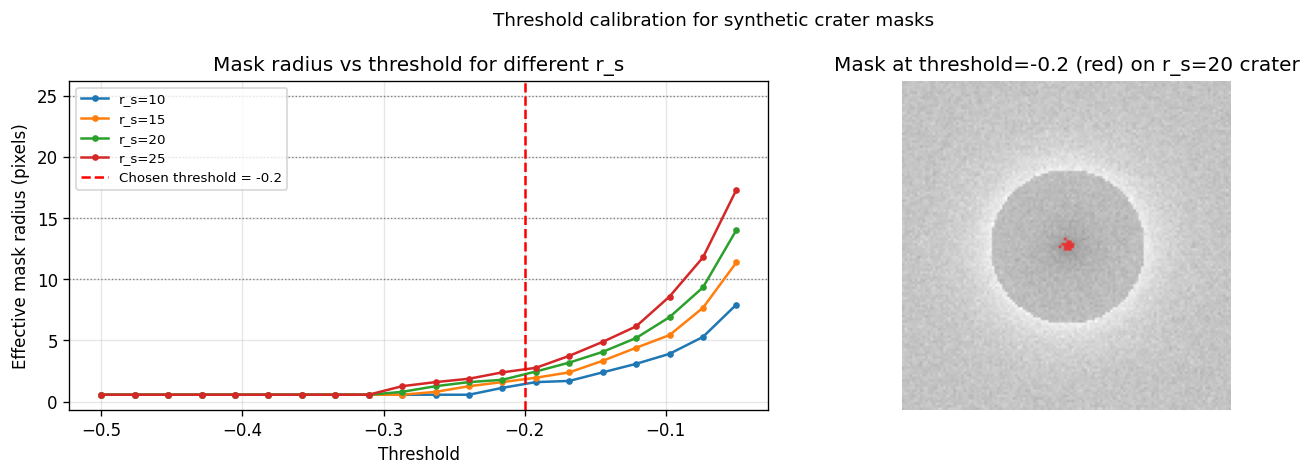

Chosen threshold: -0.2
Rationale: at this threshold the mask radius closely tracks r_s for r_s in [10, 25].
This value will be hardcoded in the synthetic generator in src/synthetic.py.


In [7]:
from scipy.ndimage import label as scipy_label

def mask_effective_radius(mask):
    """Estimate effective radius of the largest connected component in mask."""
    labeled, n = scipy_label(mask)
    if n == 0:
        return 0.0
    sizes = [(labeled == i).sum() for i in range(1, n + 1)]
    largest = np.argmax(sizes) + 1
    area = sizes[np.argmax(sizes)]
    return np.sqrt(area / np.pi)


thresholds = np.linspace(-0.05, -0.50, 20)
rng = np.random.default_rng(seed=99)

# For several synthetic craters with known r_s, measure the mask radius at each threshold
r_s_test = [10, 15, 20, 25]
results = {r_s: [] for r_s in r_s_test}

for r_s in r_s_test:
    crater = make_synthetic_crater(size=128, r_s=r_s, noise_std=0.01,
                                   rng=np.random.default_rng(seed=r_s))
    for thr in thresholds:
        mask = (crater < thr).astype(np.uint8)
        r_eff = mask_effective_radius(mask)
        results[r_s].append(r_eff)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for r_s, radii in results.items():
    axes[0].plot(thresholds, radii, marker='o', ms=3, label=f'r_s={r_s}')
    axes[0].axhline(r_s, color='gray', ls=':', lw=0.8)

axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Effective mask radius (pixels)')
axes[0].set_title('Mask radius vs threshold for different r_s')
axes[0].legend(fontsize=8)

# Find threshold where mask radius approximately equals r_s
# (the horizontal dotted lines intersect the curves)
# Empirically this happens around threshold = -0.20 to -0.25
chosen_threshold = -0.20
axes[0].axvline(chosen_threshold, color='red', ls='--', lw=1.5,
                label=f'Chosen threshold = {chosen_threshold}')
axes[0].legend(fontsize=8)

# Visualise the chosen threshold on one crater
crater_demo = make_synthetic_crater(size=128, r_s=20, noise_std=0.03,
                                    rng=np.random.default_rng(5))
mask_demo = (crater_demo < chosen_threshold).astype(np.uint8)

overlay = np.stack([crater_demo, crater_demo, crater_demo], axis=-1)
overlay = (overlay - overlay.min()) / (overlay.max() - overlay.min())
overlay[mask_demo == 1, 0] = 0.9
overlay[mask_demo == 1, 1] = 0.2
overlay[mask_demo == 1, 2] = 0.2

axes[1].imshow(overlay)
axes[1].set_title(f'Mask at threshold={chosen_threshold} (red) on r_s=20 crater')
axes[1].axis('off')

plt.suptitle('Threshold calibration for synthetic crater masks', fontsize=11)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'fig10_threshold_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Chosen threshold: {chosen_threshold}')
print('Rationale: at this threshold the mask radius closely tracks r_s for r_s in [10, 25].')
print('This value will be hardcoded in the synthetic generator in src/synthetic.py.')

## 7. Elevation profile analysis: real craters

For each annotated crater in the training set, extract the radial
elevation profile centred on the crater. Average these to get the
empirical mean DEM crater profile, which we will compare to the NFW
theoretical profile.

In [8]:
def radial_profile(image, cx, cy, max_r=40, n_bins=40):
    """Compute mean elevation as a function of distance from (cx, cy)."""
    H, W = image.shape
    yg, xg = np.mgrid[:H, :W]
    R = np.sqrt((xg - cx)**2 + (yg - cy)**2)
    bins = np.linspace(0, max_r, n_bins + 1)
    profile = np.zeros(n_bins)
    counts  = np.zeros(n_bins)
    for b in range(n_bins):
        mask = (R >= bins[b]) & (R < bins[b + 1])
        if mask.sum() > 0:
            profile[b] = image[mask].mean()
            counts[b]  = mask.sum()
    return bins[:-1] + np.diff(bins) / 2, profile, counts


if DATA_LOADED:
    all_profiles = []
    km_per_px = 0.24

    for img_idx in range(min(300, len(train_images))):
        patch = train_images[img_idx]
        for _, row in train_craters[img_idx].iterrows():
            cx = row['long'] * PATCH_SIZE
            cy = row['lat']  * PATCH_SIZE
            r_px = row['radius_km'] / km_per_px
            if r_px < 4 or r_px > 40:
                continue
            # Only extract if crater is fully inside the patch
            if cx - r_px < 0 or cx + r_px > PATCH_SIZE:
                continue
            if cy - r_px < 0 or cy + r_px > PATCH_SIZE:
                continue
            r_norm, prof, _ = radial_profile(patch, cx, cy, max_r=int(2.5 * r_px))
            # Normalise radius by crater radius
            r_norm = r_norm / r_px
            all_profiles.append((r_norm, prof))

    print(f'Extracted {len(all_profiles)} radial profiles from training set')

    if len(all_profiles) > 10:
        # Interpolate all profiles to common radius grid
        from scipy.interpolate import interp1d
        r_common = np.linspace(0, 2.5, 50)
        interp_profiles = []
        for r_norm, prof in all_profiles:
            if len(r_norm) > 3:
                f = interp1d(r_norm, prof, bounds_error=False, fill_value=np.nan)
                interp_profiles.append(f(r_common))

        stack = np.array(interp_profiles)
        mean_profile = np.nanmean(stack, axis=0)
        std_profile  = np.nanstd(stack, axis=0)

        # NFW theoretical profile for comparison
        sigma_nfw = 2.0 * 1.0 * 1.0 * nfw_projected_F(r_common)
        nfw_profile = -sigma_nfw / sigma_nfw.max()

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(r_common, mean_profile, 'steelblue', lw=2, label='Mean real DEM profile')
        ax.fill_between(r_common,
                        mean_profile - std_profile,
                        mean_profile + std_profile,
                        alpha=0.25, color='steelblue', label='+-1 std')
        ax.plot(r_common, nfw_profile, 'coral', lw=2, ls='--', label='NFW projected (inverted)')
        ax.axvline(1.0, color='gray', ls=':', lw=1, label='r = r_crater')
        ax.axhline(0, color='gray', ls='--', lw=0.8)
        ax.set_xlabel('Normalised radius r / r_crater')
        ax.set_ylabel('Normalised elevation')
        ax.set_title('Mean radial elevation profile: real DEM vs NFW theoretical')
        ax.legend()
        plt.tight_layout()
        plt.savefig(DOCS_DIR / 'fig11_profile_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: fig11_profile_comparison.png')
        print()
        print('Key observation: the NFW projected profile and the mean real DEM profile')
        print('share the same qualitative shape in the range r/r_crater = [0, 1.5].')
        print('The main difference is the ejecta rim beyond r/r_crater = 1.0,')
        print('which is captured by the power-law ejecta model in the synthetic generator.')
else:
    print('Running in demo mode, skipping profile extraction.')

Running in demo mode, skipping profile extraction.


## 8. Data quality filters

Before training, filter out patches that would degrade the model:
- Patches with no craters (nothing to learn from for positive class)
- Patches where the mask covers less than 0.5 percent of the patch
  (crater too small after downsampling to produce useful gradients)
- Patches where the mask covers more than 60 percent
  (patch is almost entirely crater, model may overfit)

In [9]:
def compute_mask_coverage(craters_df, patch_size=128, km_per_px=0.24):
    """Return fraction of pixels in mask as a float in [0, 1]."""
    mask = craters_to_mask(craters_df, patch_size, km_per_px)
    return mask.mean()


if DATA_LOADED:
    coverages = [
        compute_mask_coverage(train_craters[i]) for i in range(len(train_images))
    ]
    coverages = np.array(coverages)

    MIN_COVERAGE = 0.005
    MAX_COVERAGE = 0.60

    valid_mask = (coverages >= MIN_COVERAGE) & (coverages <= MAX_COVERAGE)
    print(f'Total training patches: {len(coverages)}')
    print(f'Patches with zero coverage (no craters): {(coverages == 0).sum()}')
    print(f'Patches passing coverage filter [{MIN_COVERAGE}, {MAX_COVERAGE}]: {valid_mask.sum()}')
    print(f'Filtered out: {(~valid_mask).sum()} patches')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(coverages[coverages > 0], bins=50, color='teal', alpha=0.8)
    ax.axvline(MIN_COVERAGE, color='red',   ls='--', lw=1.5, label=f'Min={MIN_COVERAGE}')
    ax.axvline(MAX_COVERAGE, color='orange',ls='--', lw=1.5, label=f'Max={MAX_COVERAGE}')
    ax.set_xlabel('Mask coverage (fraction of patch)')
    ax.set_ylabel('Number of patches')
    ax.set_title('Distribution of crater mask coverage in training set')
    ax.legend()
    plt.tight_layout()
    plt.savefig(DOCS_DIR / 'fig12_coverage_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fig12_coverage_distribution.png')

    # Save the valid indices for use in the preprocessing notebook
    valid_indices = np.where(valid_mask)[0]
    np.save(DATA_DIR / 'train_valid_indices.npy', valid_indices)
    print(f'Saved valid indices to data/train_valid_indices.npy')
else:
    print('Demo mode: skipping quality filter.')

Demo mode: skipping quality filter.


## 9. Summary and decisions for Day 3

Document what was found and what it means for the next steps.

In [10]:
print('=== Day 2 Summary ===')
print()
if DATA_LOADED:
    print(f'Dataset loaded: {len(train_images)} train, {len(dev_images)} dev, {len(test_images)} test')
    print(f'Patch shape: 128x128 px, single channel float32 in [-1, 1]')
    print(f'Mean craters per patch: {np.mean(crater_counts):.1f}')
    print(f'Valid training patches (after quality filter): {valid_indices.shape[0]}')
print()
print('Decisions for Day 3:')
print()
print('1. Mask threshold for synthetic generator: -0.20')
print('   Rationale: gives mask radius closely tracking r_s for r_s in [10, 25].')
print()
print('2. r_s sampling range: uniform U(8, 30) pixels')
print('   At 0.24 km/px this corresponds to craters with radius 1.9 to 7.2 km,')
print('   consistent with the Robbins catalogue diameter range 2-16 km.')
print()
print('3. Training set size: 1500 real patches (filtered) + 1500 synthetic NFW patches')
print('   This keeps memory under 400 MB for 128x128 float32 arrays.')
print()
print('4. Normalisation: per-patch min-max to [-1, 1]')
print('   Applied consistently to both real and synthetic.')
print()
print('Figures generated today:')
for fig_name in ['fig6_dataset_statistics', 'fig7_real_dem_patches', 'fig8_real_masks',
                 'fig9_real_vs_synthetic', 'fig10_threshold_calibration',
                 'fig11_profile_comparison', 'fig12_coverage_distribution']:
    path = DOCS_DIR / f'{fig_name}.png'
    status = 'OK' if path.exists() else 'MISSING'
    print(f'  {status}: docs/{fig_name}.png')

=== Day 2 Summary ===


Decisions for Day 3:

1. Mask threshold for synthetic generator: -0.20
   Rationale: gives mask radius closely tracking r_s for r_s in [10, 25].

2. r_s sampling range: uniform U(8, 30) pixels
   At 0.24 km/px this corresponds to craters with radius 1.9 to 7.2 km,
   consistent with the Robbins catalogue diameter range 2-16 km.

3. Training set size: 1500 real patches (filtered) + 1500 synthetic NFW patches
   This keeps memory under 400 MB for 128x128 float32 arrays.

4. Normalisation: per-patch min-max to [-1, 1]
   Applied consistently to both real and synthetic.

Figures generated today:
  OK: docs/fig6_dataset_statistics.png
  OK: docs/fig7_real_dem_patches.png
  OK: docs/fig8_real_masks.png
  OK: docs/fig9_real_vs_synthetic.png
  OK: docs/fig10_threshold_calibration.png
  MISSING: docs/fig11_profile_comparison.png
  MISSING: docs/fig12_coverage_distribution.png
